In [19]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

## set data

In [20]:
# Import ai industry csv using pandas - it exists one dir up and in Data
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 


## AI Company Adoption CSV 

In [22]:
df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

## Country AI Index CSV 

In [23]:
df_country = pd.read_csv("../Data/country_ai_index.csv") 

Next is the basic bar chart set to show spread of AI adoption across industry

Text(0, 0.5, 'AI Adoption Rate %')

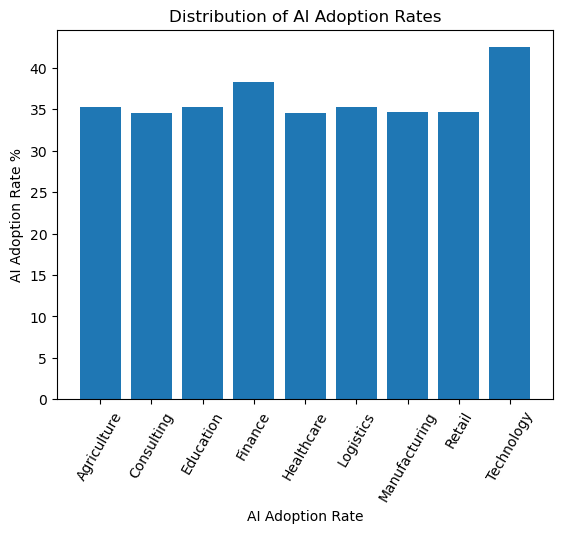

In [24]:
# Plot bar chart of AI Adoption Rates by Industry
plt.bar(df_industry['industry'], df_industry["avg_ai_adoption_rate"])
plt.title("Distribution of AI Adoption Rates")
plt.xticks(rotation=60)
plt.xlabel("AI Adoption Rate")
plt.ylabel("AI Adoption Rate %")

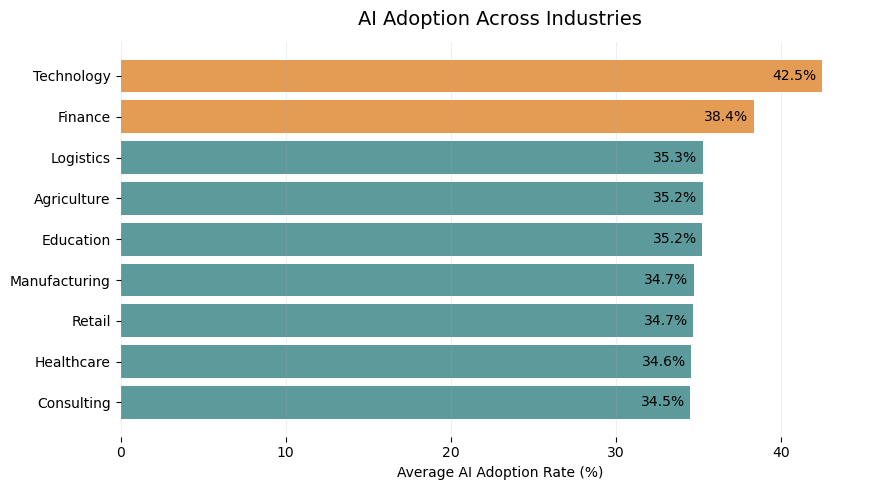

In [40]:
import matplotlib.pyplot as plt

df_industry_sorted = df_industry.sort_values(
    "avg_ai_adoption_rate",
    ascending=True
)

colors = [
    "#e49c54" if industry in ["Technology", "Finance"] else "#5d9a9c"
    for industry in df_industry_sorted["industry"]
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    df_industry_sorted["industry"],
    df_industry_sorted["avg_ai_adoption_rate"],
    color=colors
)
for bar in bars:
    width = bar.get_width()

    ax.text(
        width - 3 ,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

ax.set_title(
    "AI Adoption Across Industries",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Average AI Adoption Rate (%)")
ax.set_ylabel("")

ax.set_xlim(0, 46)
ax.grid(axis="x", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
#calculation for choropleth
country_ai = (
    df_company
    .groupby("country")["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_ai.head()

,country,ai_adoption_rate
0,Argentina,34.327419
1,Australia,39.933564
2,Brazil,36.674198
3,Canada,39.120333
4,Chile,36.461705


In [46]:
fig = px.choropleth(
    country_ai,
    locations="country",
    locationmode="country names",
    color="ai_adoption_rate",
    hover_name="country",
    color_continuous_scale="Plasma",
    range_color=(30,41),
    projection="natural earth",
    labels={
        "ai_adoption_rate": "Avg AI Adoption Rate (%)"
    },
    title="Global AI Adoption Intensity by Country"
)


fig.update_traces(
    marker_line_color="white",
    marker_line_width=0.4,
    hovertemplate=
        "<b>%{hovertext}</b><br>" +
        "AI Adoption Rate: %{z:.1f}%<extra></extra>"
)


fig.update_layout(

    # background
    paper_bgcolor="rgb(245,248,250)",
    plot_bgcolor="rgb(245,248,250)",

    title={
        "text": "Global AI Adoption Intensity by Country",
        "x": .5,
        "xanchor": "center",
        "font": {
            "size": 24,
            "color": "rgb(30,30,30)"
        }
    },

    geo=dict(
        showframe=False,
        showcoastlines=True,

        # the good stuff
        showocean=True,
        oceancolor="#3FAAA5",

        showland=True,
        landcolor="rgb(215,220,220)",

        coastlinecolor="white",
        countrycolor="white",

        projection_type="natural earth"
    ),

    coloraxis_colorbar=dict(
        title="AI Adoption<br>Rate (%)",
        ticksuffix="%",
        thickness=15
    ),

    margin=dict(
        l=20,
        r=20,
        t=70,
        b=20
    )
)


fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_48364\15320097.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
